## **Overview**

This project revisits a scientific-programming exercise on **three-body bond-angle distributions** in model atomic systems. I use it to explore both structural information contained in bond-angle distributions and the numerical choices involved in neighbour identification. The original coursework implementation and accompanying write-up have been reorganised and annotated here as part of my later revision.

To keep it concise this work mainly contains the code. Discussions are made in the explanary text.



## **Objective**
The model is deliberately simple, providing an intuitive setting in which the relationship between atomic arrangement and local three-body geometry can be examined directly. By changing the degree and type of structural order while keeping the underlying analysis consistent, the same framework can be used to observe how bond-angle distributions respond to increasingly different atomic environments. More realistic physical effects can subsequently be incorporated on top of this basic framework.

Specifically, the project considers four related structural scenarios:

1. *General periodic configuration*:
How can local three-body geometry be defined and computed consistently in a finite simulation cell representing an infinite periodic system?

2. *Ordered atomic structure*:
How is structural order reflected in the bond-angle distribution?

3. *Positional disorder / perturbed structure*:
How does the bond-angle distribution change when atoms are displaced from their ideal lattice positions?

4. *Uncorrelated reference system*:
What does the bond-angle distribution look like in the absence of underlying structural order? We discuss the ideal gas configuration for example.

From a computational perspective, the main focus is the **neighbour-identification step**, which forms the numerical bottleneck of the bond-angle calculation. **Four** approaches are investigated: ***brute-force search, a vectorised implementation, KD-tree search, and a cell-linked-list method***. Their results are compared not only for computational efficiency and scalability, but also for numerical consistency, so that improvements in performance do not come at the expense of the accuracy of the calculated bond-angle distributions.




In [1]:
import sys
print(sys.executable)

d:\00_2026_phd_application\Computational_Practice_MSc\.venv\Scripts\python.exe


## **Building the simulation system**
The first step is to define the simulation cell and then populate it with particles.
In this project, I use two different approaches to construct the atomic system. The first approach is a simple implementation written directly in NumPy. A general periodic cell is defined using three lattice vectors, and particles can then be placed inside the cell either randomly or in a regular ordered array(Ojective1&2). This provides a simple framework for comparing disordered and ordered configurations while keeping the underlying analysis unchanged.
Randomly populated cells are useful for constructing an uncorrelated reference configuration, while regularly ordered arrays provide a simple model for examining how structural order appears in the bond-angle distribution.
The second approach uses ASE. For standard physical crystal structures, ASE provides a more convenient way to generate predefined lattices and supercells, such as FCC, BCC and diamond structures. This is useful when moving from the simple geometric models above to more realistic atomic structures.

In [2]:
import numpy as np


def make_cell(a, b, c):
    """
    Construct a 3D periodic simulation cell from three linearly independent cell vectors(lattice vector).
    Lattice vectors defining the size and shape of the simulation cell.
    Cartesian components are given in angstroms (Å).
    Returns cell : ndarray, shape (3, 3)
    Cell vectors stored as rows(row vectors).
    """
    cell = np.array([a, b, c], dtype=float)

    if cell.shape != (3, 3):
        raise ValueError("A 3D cell must contain three 3D vectors.")

    if np.isclose(np.linalg.det(cell), 0.0):
        raise ValueError("Cell vectors must be linearly independent.")

    return cell

### **Periodic boundary conditions**

Periodic boundary conditions are important for the following parts of this project.

At this stage, the simulation cell has already been defined. The next step is to populate the cell with particles. When generating particle positions, we do not want two particles to be placed too close to each other or to overlap. Therefore, when checking the separation between a newly generated particle and the particles already in the cell, periodic boundary conditions need to be considered. This is because simply calculating the Euclidean distance between two Cartesian positions is not always sufficient in a periodic system. Two particles may appear to be far apart inside the primary simulation cell, while their nearest periodic images are actually very close to each other.

The same issue also appears later during neighbour searching. A particle close to one boundary of the simulation cell may be a neighbour of another particle close to the opposite boundary. Therefore, the minimum-image displacement should be used before calculating the interparticle distance.

The *pbc()* function below is therefore used both during particle generation and during neighbour identification.

In [3]:
def pbc(displacement, cell):
    """
    This function applies periodic boundary conditions to a Cartesian displacement vector
    and finds the shortest equivalent displacement under periodicity, where

    displacement : array_like, shape (3,) Cartesian displacement vector between two atoms.
    cell : ndarray, shape (3, 3) Cell vectors stored as rows.

    Returns
    -------
    ndarray, shape (3,)
        Minimum-image displacement vector in Cartesian coordinates.
    """
    fractional = displacement @ np.linalg.inv(cell)
    fractional -= np.round(fractional)

    return fractional @ cell

Too keep things in general we populate the box with particles at random position(objective 1). To avoid unrealistically close particle pairs, a minimum allowed interparticle separation is introduced during random particle generation.

In [4]:
def generate_random_positions(n_particles, cell, min_distance, seed=None):

    """ The function is used to generate random particles, where
        
        n_particles: number of particles
        cell: simulation cell
        min_distance:the minimum distance between two particles to avoild unphysically overlap or close particle pairs 
    
    """

    rng = np.random.default_rng(seed)
    positions = []

    while len(positions) < n_particles:

        fractional_position = rng.random(3)
        candidate = fractional_position @ cell

        valid = True

        for position in positions:

            displacement = candidate - position
            displacement = pbc(displacement, cell)

            distance = np.linalg.norm(displacement)

            if distance < min_distance:
                valid = False
                break

        if valid:
            positions.append(candidate)

    return np.array(positions)

In [5]:
def generate_ordered_positions(cell, n_a, n_b, n_c):
    """
    Generate regularly spaced particle positions inside a periodic cell.

    The ordered grid is first constructed in fractional coordinates
    and then transformed into Cartesian coordinates.
    """
    positions = []

    for i in range(n_a):
        for j in range(n_b):
            for k in range(n_c):

                fractional = np.array([
                    i / n_a,
                    j / n_b,
                    k / n_c
                ])

                position = fractional @ cell
                positions.append(position)

    return np.array(positions)

Alternatively, Generating physical crystal structures with ASE
The ordered array above is a simple geometric construction. For standard crystal structures, it is more convenient to use established tools such as ASE, which can generate common lattices and supercells directly.

In [6]:
from ase.build import bulk
from ase.visualize import view

#primitive cells
# FCC aluminium
al_fcc = bulk("Al", "fcc", a=4.05)

# BCC iron
fe_bcc = bulk("Fe", "bcc", a=2.87)

# Diamond silicon
si_diamond = bulk("Si", "diamond", a=5.43)

In [7]:
#Al as example
al_supercell = al_fcc.repeat((3, 3, 3))
print(al_supercell.cell)
print(al_supercell.positions)
view(al_supercell)

Cell([[0.0, 6.074999999999999, 6.074999999999999], [6.074999999999999, 0.0, 6.074999999999999], [6.074999999999999, 6.074999999999999, 0.0]])
[[0.    0.    0.   ]
 [2.025 2.025 0.   ]
 [4.05  4.05  0.   ]
 [2.025 0.    2.025]
 [4.05  2.025 2.025]
 [6.075 4.05  2.025]
 [4.05  0.    4.05 ]
 [6.075 2.025 4.05 ]
 [8.1   4.05  4.05 ]
 [0.    2.025 2.025]
 [2.025 4.05  2.025]
 [4.05  6.075 2.025]
 [2.025 2.025 4.05 ]
 [4.05  4.05  4.05 ]
 [6.075 6.075 4.05 ]
 [4.05  2.025 6.075]
 [6.075 4.05  6.075]
 [8.1   6.075 6.075]
 [0.    4.05  4.05 ]
 [2.025 6.075 4.05 ]
 [4.05  8.1   4.05 ]
 [2.025 4.05  6.075]
 [4.05  6.075 6.075]
 [6.075 8.1   6.075]
 [4.05  4.05  8.1  ]
 [6.075 6.075 8.1  ]
 [8.1   8.1   8.1  ]]


<Popen: returncode: None args: ['d:\\00_2026_phd_application\\Computational_...>

## **Neighbor List Search**
For the following neighbour-search tests, a simple cubic simulation cell is used so that the geometry remains easy to inspect while the search algorithms are compared under the same conditions.

In [8]:
a = np.array([10.0, 0.0, 0.0])
b = np.array([0.0, 10.0, 0.0])
c = np.array([0.0, 0.0, 10.0])

cell = make_cell(a, b, c)

To compare the effect of structural order, the ordered and random systems are constructed using the same simulation cell and the same number of particles. This keeps the number density fixed, so differences in the resulting bond-angle distributions arise primarily from the particle arrangement. The following shows two examples with simulation box length of $10\ \text{Å}$ and 27 particles in the box. The points shown in the diagram therefore indicate particle positions rather than their physical sizes.


In [ ]:
#System Setup Cell
L = 10.0 #box length
N = 27   #number of particles in one simulation cell

In [10]:
random_positions = generate_random_positions(
    n_particles=27,
    cell=cell,
    min_distance=0.8,
    seed=42
)


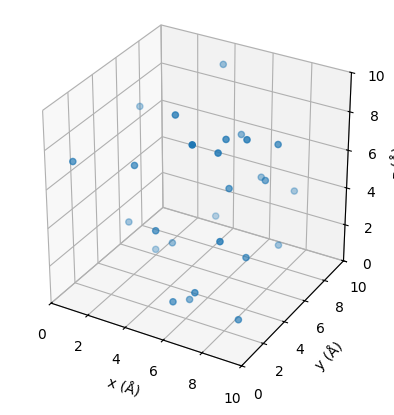

In [11]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    random_positions[:, 0],
    random_positions[:, 1],
    random_positions[:, 2]
)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)

ax.set_box_aspect((1, 1, 1))

plt.show()

In [12]:
ordered_positions = generate_ordered_positions(
    cell=cell,
    n_a=3,
    n_b=3,
    n_c=3
)

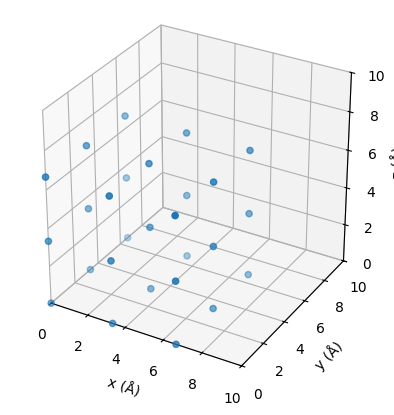

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ordered_positions[:, 0],
    ordered_positions[:, 1],
    ordered_positions[:, 2]
)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")

ax.set_box_aspect((1, 1, 1))

plt.show()

After constructing the simulation system, the next step is to identify the neighbouring particles around a selected central particle.
A cutoff distance is used to define the local environment. Periodic boundary conditions are applied to the displacement vectors before calculating distances, so that neighbours across the simulation-cell boundaries are also identified correctly.

The **box length** and **cutoff distance** used here are chosen only for demonstration. They are not intended to represent a specific physical system. In practical applications, these parameters should be selected according to the particle density, characteristic interatomic distances, and the structural features of interest.

In [14]:
center_idx = 0
cutoff = 4.0

For the ordered example used here, the $3\times3\times3$ particle array is distributed uniformly inside a cubic simulation cell of length $10\ \text{Å}$. The characteristic nearest-neighbour spacing is therefore approximately
$$
\frac{10}{3} \approx 3.33\,\text{Å}.
$$

The neighbour cutoff should be chosen with this spacing in mind. If the cutoff is smaller than about $3.33\ \text{Å}$, the first nearest-neighbour shell may not be identified. A cutoff slightly larger than this value, for example $3.4$–$3.6\ \text{Å}$, mainly captures the nearest neighbours. In the simple demonstration below, a cutoff of $4.0\ \text{Å}$ is used to provide some tolerance while still focusing on the first local coordination shell.
This cutoff is chosen only for the present toy model. In a realistic atomic system, the cutoff would normally be selected according to the characteristic interatomic distances and the coordination structure of the material being studied.

In [20]:
from neighbor_search.brute_force import find_neighbors_brute_force

neighbors_bf_ordered = find_neighbors_brute_force(

    positions=ordered_positions,
    center_idx=center_idx,
    cutoff=cutoff,
    cell=cell
)

In [ ]:
print(neighbors_bf_ordered)

[(1, array([0.        , 0.        , 3.33333333])), (2, array([ 0.        ,  0.        , -3.33333333])), (3, array([0.        , 3.33333333, 0.        ])), (6, array([ 0.        , -3.33333333,  0.        ])), (9, array([3.33333333, 0.        , 0.        ])), (18, array([-3.33333333,  0.        ,  0.        ]))]


Because periodic boundary conditions are applied, neighbours across opposite boundaries of the simulation cell are included in the same way as neighbours within the **primary cell**. Some neighbours appear visually distant from the central particle when plotted using their coordinates in the primary simulation cell. Under periodic boundary conditions, however, particles near the opposite boundary correspond to nearby periodic images and can therefore fall within the cutoff distance.

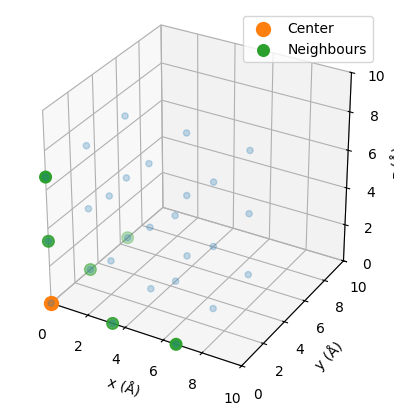

In [ ]:
# Visualization:primiary cell representation
center = ordered_positions[center_idx]

neighbor_indices = [idx for idx, _ in neighbors_bf_ordered]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# all particles
ax.scatter(
    ordered_positions[:, 0],
    ordered_positions[:, 1],
    ordered_positions[:, 2],
    alpha=0.25
)

# center particle
ax.scatter(
    center[0],
    center[1],
    center[2],
    s=100,
    label="Center"
)

# neighbour particles
neighbor_positions = ordered_positions[neighbor_indices]

ax.scatter(
    neighbor_positions[:, 0],
    neighbor_positions[:, 1],
    neighbor_positions[:, 2],
    s=70,
    label="Neighbours"
)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_box_aspect((1, 1, 1))

ax.legend()

plt.show()

The image above shows the **central particle**(indicated in orange) and the **neighbours**(indicated in green) identified within the cutoff distance under **brute force neighbor search** , plotted using their original coordinates in the primary simulation cell. Some neighbours appear visually far from the central particle because they lie close to the opposite boundary of the cell. Under periodic boundary conditions, these particles correspond to nearby periodic images and are therefore correctly identified as neighbours.

In [22]:
neighbor_image_positions = np.array([
    center + displacement
    for _, displacement in neighbors_bf_ordered
])

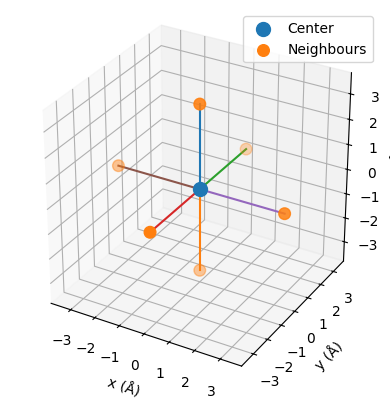

In [ ]:
#Visualization: minimum-image representation
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# center
ax.scatter(
    center[0],
    center[1],
    center[2],
    s=100,
    label="Center"
)

# nearest periodic images of neighbours
ax.scatter(
    neighbor_image_positions[:, 0],
    neighbor_image_positions[:, 1],
    neighbor_image_positions[:, 2],
    s=70,
    label="Neighbours"
)

# optional: connect center to neighbours
for position in neighbor_image_positions:
    ax.plot(
        [center[0], position[0]],
        [center[1], position[1]],
        [center[2], position[2]]
    )

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_box_aspect((1, 1, 1))
ax.legend()

plt.show()

The second image shows the same local environment using the minimum-image representation. Each neighbour is repositioned according to its PBC-corrected displacement from the central particle. In this representation, the neighbours form the local coordination environment around the centre more directly, and the periodic neighbours that appeared distant in the primary cell are now shown at their nearest equivalent positions.
**This minimum-image representation is also the one used in the subsequent bond-angle calculation**, because both the neighbour distances and the relative directions between neighbouring particles must be defined using the PBC-corrected displacement vectors.